# Monitoramento de Drift — Passos Mágicos

Compara a distribuição das features de entrada dos dados novos com a distribuição do treino.
Se as distribuições mudarem muito, pode ser sinal de que o modelo precisa ser retreinado.

In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.preprocessing import load_raw_data, clean_data, NUMERIC_FEATURES
from src.feature_engineering import create_features

## 1. Dados de referência (treino)

In [2]:
df_raw = load_raw_data()
df_ref = clean_data(df_raw)
df_ref = create_features(df_ref)

feature_cols = [c for c in NUMERIC_FEATURES if c in df_ref.columns]
X_ref = df_ref[feature_cols].dropna()

print(f"referência: {X_ref.shape[0]} amostras")
X_ref.describe().round(2)

2026-03-08 21:08:13,320 [INFO] preprocessing: carregou base_2024.xlsx: 860 linhas
referência: 860 amostras


,fase,idade,anos_no_programa,inde,iaa,ieg,ips,ida,ipv,cg,cf,ct,matem,portug
count,860.00,860.00,860.00,860.00,860.00,860.00,860.00,860.00,860.00,860.00,860.00,860.00,860.00,860.00
mean,2.10,12.14,2.50,7.04,8.27,7.89,6.90,6.09,7.25,430.52,75.52,6.60,5.81,6.32
std,1.79,2.77,1.79,1.02,2.06,1.64,1.07,2.05,1.09,248.43,52.31,3.98,2.41,2.08
min,0.00,7.00,1.00,3.03,0.00,0.00,2.50,0.00,2.50,1.00,1.00,1.00,0.00,0.00
25%,1.00,10.00,1.00,6.49,7.90,7.00,6.30,4.80,6.72,215.75,30.00,3.00,4.30,5.20
50%,2.00,12.00,2.00,7.20,8.80,8.30,7.50,6.30,7.33,430.50,67.00,6.00,6.00,6.70
75%,3.00,14.00,4.00,7.75,9.50,9.10,7.50,7.60,7.92,645.25,118.00,9.00,7.80,7.80
max,7.00,21.00,7.00,9.44,10.00,10.00,10.00,9.90,10.00,862.00,192.00,18.00,10.00,10.00


## 2. Dados novos (produção)

Em produção os dados viriam dos logs do `/predict`. Aqui simulamos um batch novo com drift em `inde` e `iaa` para testar o monitoramento.

In [3]:
rng = np.random.default_rng(seed=99)

# amostra aleatória dos dados de treino + ruído
idx = rng.integers(0, len(X_ref), size=200)
X_prod = X_ref.iloc[idx].copy().reset_index(drop=True)
X_prod += rng.normal(0, 0.3, size=X_prod.shape)

# drift intencional em inde e iaa pra testar
for col in ("inde", "iaa"):
    X_prod[col] += 1.5 * X_ref[col].std()

print(f"produção simulada: {len(X_prod)} amostras")
X_prod.describe().round(2)

produção simulada: 200 amostras


,fase,idade,anos_no_programa,inde,iaa,ieg,ips,ida,ipv,cg,cf,ct,matem,portug
count,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00
mean,2.06,12.15,2.59,8.54,11.49,7.80,6.92,5.95,7.23,435.27,77.67,6.43,5.77,6.05
std,1.67,2.74,1.77,1.16,2.12,1.69,1.10,2.15,1.17,261.59,54.75,4.23,2.35,2.28
min,-0.55,6.51,-0.07,5.28,2.60,2.75,4.36,-0.20,3.72,2.06,1.01,0.49,-0.56,-0.52
25%,0.73,9.91,1.13,7.78,11.05,6.90,6.15,4.72,6.49,213.78,29.06,2.84,4.24,4.96
50%,1.92,11.91,1.89,8.63,12.01,8.10,7.30,6.34,7.41,438.94,71.29,6.15,5.78,6.54
75%,3.12,14.05,3.98,9.37,12.61,9.09,7.66,7.53,7.92,653.10,116.52,9.36,7.68,7.69
max,6.88,19.42,7.21,11.22,13.66,10.51,10.31,10.28,10.06,860.40,191.50,16.63,10.25,9.93


## 3. Comparação das médias

Primeira checagem rápida: se a média de alguma feature mudou muito, já é um sinal de alerta.

In [4]:
comparacao = pd.DataFrame({
    "media_treino": X_ref.mean().round(3),
    "media_producao": X_prod.mean().round(3),
    "diferenca": (X_prod.mean() - X_ref.mean()).round(3),
})
comparacao["variacao_%"] = (comparacao["diferenca"] / comparacao["media_treino"] * 100).round(1)
comparacao.sort_values("variacao_%", key=abs, ascending=False)

,media_treino,media_producao,diferenca,variacao_%
iaa,8.274,11.492,3.217,38.9
inde,7.036,8.541,1.504,21.4
portug,6.322,6.047,-0.275,-4.3
anos_no_programa,2.503,2.585,0.082,3.3
cf,75.520,77.668,2.148,2.8
ct,6.599,6.427,-0.172,-2.6
ida,6.093,5.951,-0.142,-2.3
fase,2.099,2.055,-0.044,-2.1
ieg,7.891,7.797,-0.094,-1.2
cg,430.516,435.269,4.753,1.1


## 4. Distribuição das principais features

Histogramas das features mais importantes para o modelo.

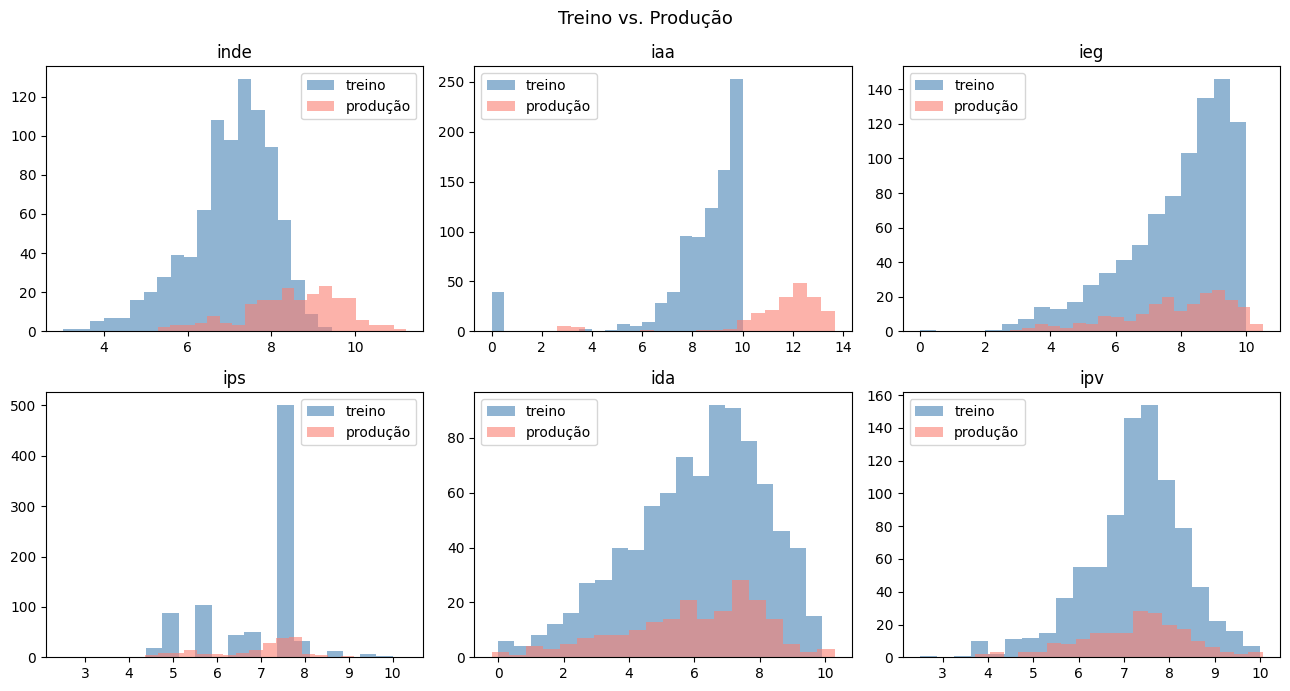

In [5]:
# foco nas features mais relevantes pro modelo
features_principais = ["inde", "iaa", "ieg", "ips", "ida", "ipv"]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for i, col in enumerate(features_principais):
    ax = axes[i]
    ax.hist(X_ref[col], bins=20, alpha=0.6, label="treino", color="steelblue")
    ax.hist(X_prod[col], bins=20, alpha=0.6, label="produção", color="salmon")
    ax.set_title(col)
    ax.legend()

plt.suptitle("Treino vs. Produção", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Teste KS nas features principais

O teste Kolmogorov-Smirnov verifica se duas distribuições são significativamente diferentes.
p-value < 0.05 indica drift.

In [6]:
resultados = []
for col in features_principais:
    ks, p = stats.ks_2samp(X_ref[col].dropna(), X_prod[col].dropna())
    resultados.append({"feature": col, "ks": round(ks, 4), "p_value": round(p, 4), "drift": p < 0.05})

df_ks = pd.DataFrame(resultados)
print(df_ks.to_string(index=False))

drift_detectado = df_ks[df_ks["drift"]]
if len(drift_detectado) > 0:
    print(f"\nAtenção: drift em {list(drift_detectado['feature'])} — considere retreinar o modelo")
else:
    print("\nNenhum drift significativo detectado")

feature     ks  p_value  drift
   inde 0.5641   0.0000   True
    iaa 0.9200   0.0000   True
    ieg 0.0938   0.1070  False
    ips 0.2942   0.0000   True
    ida 0.0495   0.7998  False
    ipv 0.0692   0.3990  False

Atenção: drift em ['inde', 'iaa', 'ips'] — considere retreinar o modelo


## 6. Distribuição das predições ao longo do tempo

Se a proporção de alunos em "Alto Risco" aumentar muito, pode indicar mudança no perfil dos alunos ou degradação do modelo.

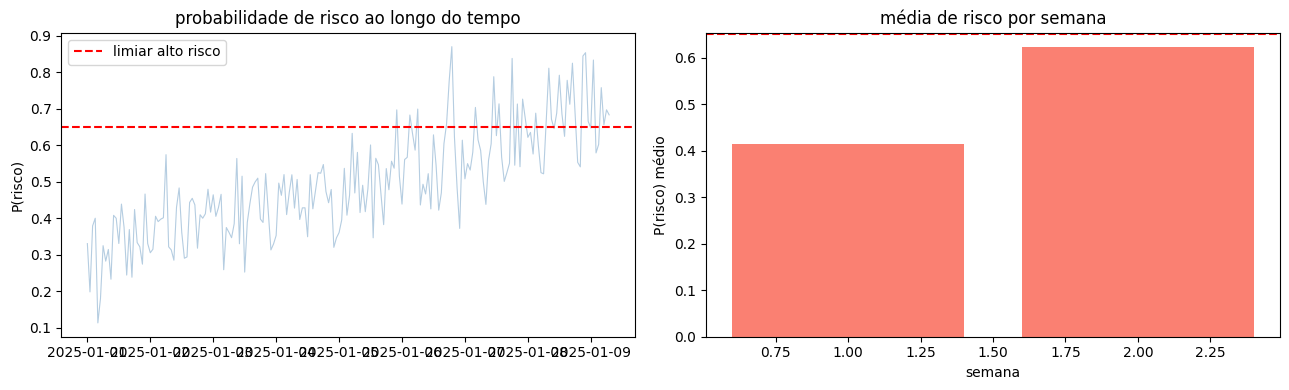

In [7]:
# simula predições com drift gradual ao longo do tempo
rng2 = np.random.default_rng(seed=42)
probs = np.clip(np.linspace(0.3, 0.7, 200) + rng2.normal(0, 0.1, 200), 0, 1)
datas = pd.date_range("2025-01-01", periods=200, freq="1h")

df_preds = pd.DataFrame({"data": datas, "risco": probs})

# agrupa por semana
df_preds["semana"] = df_preds["data"].dt.isocalendar().week
semanal = df_preds.groupby("semana")["risco"].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(df_preds["data"], df_preds["risco"], alpha=0.4, color="steelblue", linewidth=0.8)
ax1.axhline(0.65, color="red", linestyle="--", label="limiar alto risco")
ax1.set_title("probabilidade de risco ao longo do tempo")
ax1.set_ylabel("P(risco)")
ax1.legend()

ax2.bar(semanal.index, semanal.values, color="salmon")
ax2.axhline(0.65, color="red", linestyle="--")
ax2.set_title("média de risco por semana")
ax2.set_xlabel("semana")
ax2.set_ylabel("P(risco) médio")

plt.tight_layout()
plt.show()

## Conclusão

Com base na análise acima é possível identificar se o perfil dos alunos mudou em relação ao período de treino.
Se houver drift em features importantes (`inde`, `iaa`), o recomendado é coletar os dados novos, rotular e retreinar o modelo.